```Breast Cancer Wisconsin```

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Basic info
print("Classes:", data.target_names)
print("Feature shape:", X.shape)
X.head()

Classes: ['malignant' 'benign']
Feature shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

``` AdaBoost```

In [3]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=50,     # Number of weak learners
    learning_rate=1.0,   # Weight of each weak learner
    random_state=42
)
ada.fit(X_train, y_train)

AdaBoostClassifier(random_state=42)

```Gradient Boosting```

In [4]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,    # Number of boosting stages
    learning_rate=0.1,   # Shrinks contribution of each tree
    max_depth=3,         # Depth of individual trees
    random_state=42
)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

```XGBoost```

In [5]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:24:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [6]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, y_test, y_pred, name):
    print(f"\n{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

y_pred_ada = ada.predict(X_test)
y_pred_gb = gb.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

evaluate_model(ada, y_test, y_pred_ada, "AdaBoost")
evaluate_model(gb, y_test, y_pred_gb, "Gradient Boosting")
evaluate_model(xgb, y_test, y_pred_xgb, "XGBoost")


AdaBoost Accuracy: 0.9561
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Gradient Boosting Accuracy: 0.9561
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


XGBoost Accuracy: 0.9474
              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      

``` ROC-AUC Curve Comparison```

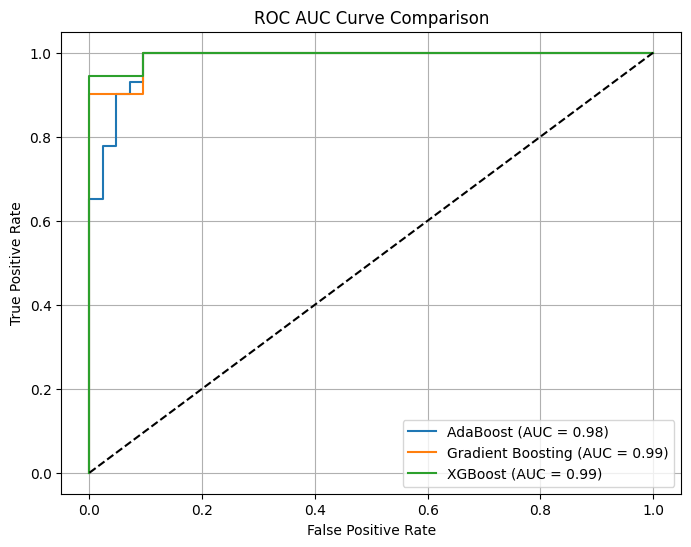

In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc(models, model_names):
    plt.figure(figsize=(8, 6))

    for model, name in zip(models, model_names):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--')  # Random guess line
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC AUC Curve Comparison")
    plt.legend()
    plt.grid()
    plt.show()

plot_roc([ada, gb, xgb], ["AdaBoost", "Gradient Boosting", "XGBoost"])

``` Feature Importance Visualization```

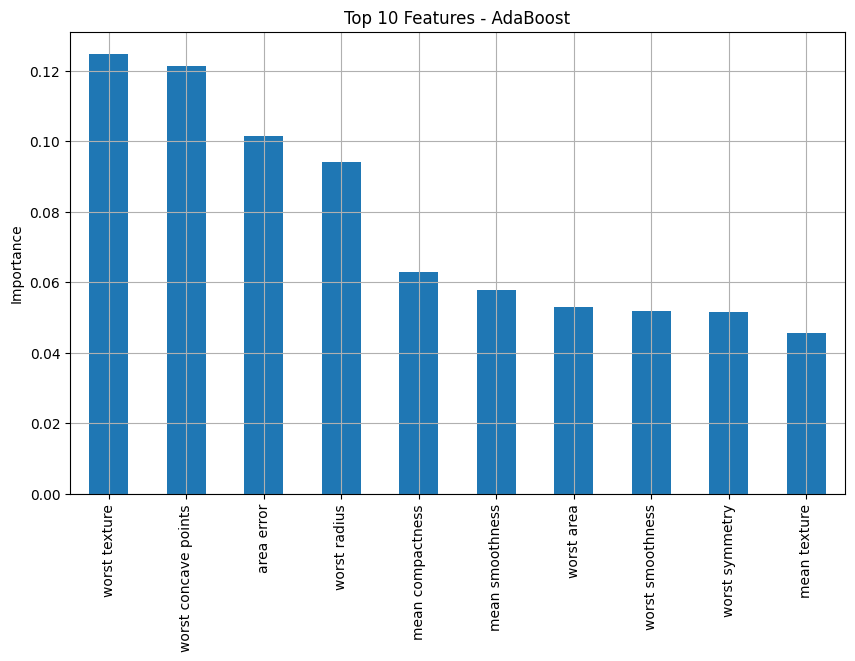

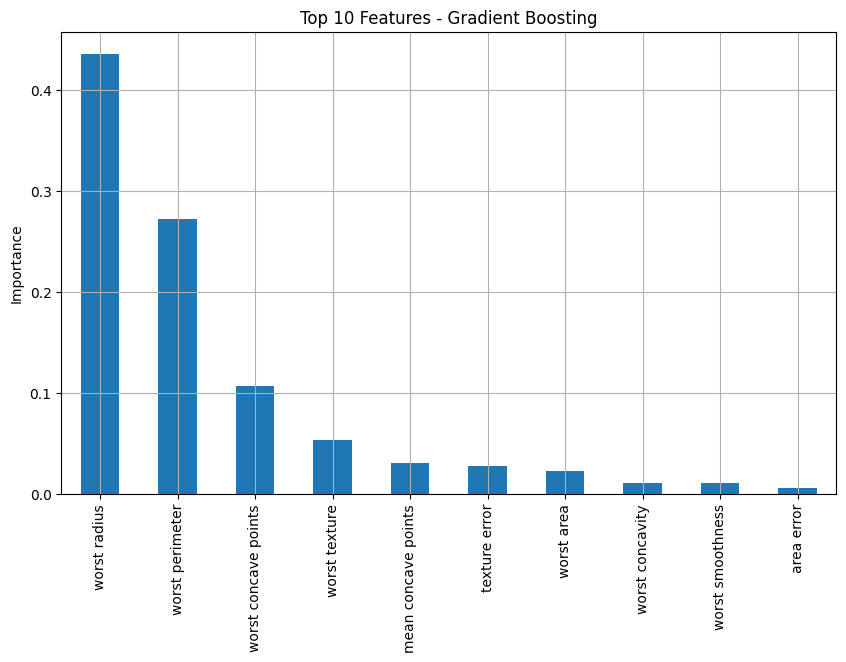

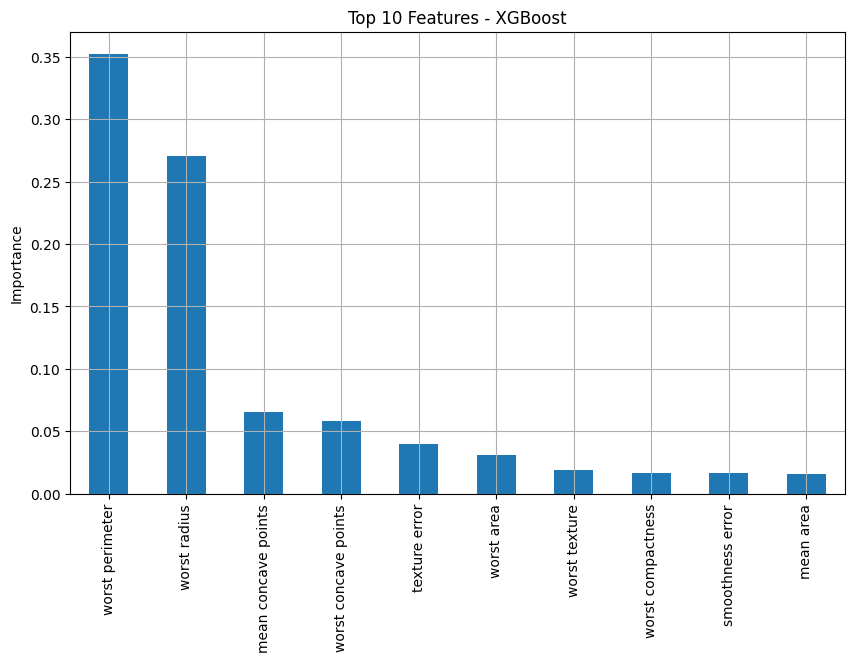

In [8]:
import seaborn as sns

def plot_feature_importance(model, name):
    importance = model.feature_importances_
    feat_df = pd.Series(importance, index=X.columns)

    plt.figure(figsize=(10, 6))
    feat_df.sort_values(ascending=False).head(10).plot(kind='bar')
    plt.title(f"Top 10 Features - {name}")
    plt.ylabel("Importance")
    plt.grid()
    plt.show()

plot_feature_importance(ada, "AdaBoost")
plot_feature_importance(gb, "Gradient Boosting")
plot_feature_importance(xgb, "XGBoost")

```Summary Table of Accuracy```

In [9]:
accuracy_table = pd.DataFrame({
    'Model': ['AdaBoost', 'Gradient Boosting', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

print(accuracy_table)

               Model  Accuracy
0           AdaBoost  0.956140
1  Gradient Boosting  0.956140
2            XGBoost  0.947368
